<a href="https://colab.research.google.com/github/Akajiaku11/ML-AI-Elevation/blob/main/Copy_of_Untitled50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install core geospatial libraries
!pip install geopandas rasterio fiona shapely folium matplotlib seaborn pandas numpy
!pip install scikit-image opencv-python pillow
!pip install contextily  # For basemaps
!pip install rasterstats  # For zonal statistics

In [ ]:
import geopandas as gpd
import rasterio
from rasterio.plot import show
from rasterio.mask import mask
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point, box, Polygon
import folium
from folium import GeoJson
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [ ]:
# Create directories
import os
os.makedirs('data', exist_ok=True)
os.chdir('data')

# Download sample raster data (DEM)
!wget -q https://cloud.sdsc.edu/v1/AUTH_opentopography/Raster/SRTM_GL30/SRTM_GL30_srtm/SRTM_GL30_srtm_srtm.tar.gz -O sample_dem.tar.gz 2>/dev/null || echo "Alternative: Using generated raster"

# Download sample vector data (Natural Earth)
!wget -q https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip -O countries.zip
!unzip -q countries.zip 2>/dev/null || echo "Natural Earth data"

# If downloads fail, we'll create synthetic data
print("Sample data preparation complete")
os.chdir('..')

Alternative: Using generated raster
Sample data preparation complete


In [ ]:
from rasterio.transform import Affine
from rasterio.crs import CRS

# Create a synthetic DEM (Digital Elevation Model)
def create_sample_raster():
    # Create synthetic elevation data
    x = np.linspace(0, 10, 100)
    y = np.linspace(0, 10, 100)
    X, Y = np.meshgrid(x, y)
    elevation = 1000 + 500 * np.sin(X/5) * np.cos(Y/5)

    # Save as GeoTIFF
    transform = Affine(0.1, 0, 0, 0, -0.1, 10)  # 100m pixels
    crs = CRS.from_epsg(4326)

    with rasterio.open(
        'data/sample_dem.tif',
        'w',
        driver='GTiff',
        height=elevation.shape[0],
        width=elevation.shape[1],
        count=1,
        dtype=elevation.dtype,
        crs=crs,
        transform=transform,
    ) as dst:
        dst.write(elevation, 1)

    print("✓ Sample raster created: data/sample_dem.tif")
    return elevation

elevation_data = create_sample_raster()

✓ Sample raster created: data/sample_dem.tif


In [ ]:
from shapely.geometry import box, Point, Polygon

# Create sample vector data (points, lines, polygons)
def create_sample_vectors():
    # Create points
    points_data = {
        'id': [1, 2, 3, 4, 5],
        'name': ['Site A', 'Site B', 'Site C', 'Site D', 'Site E'],
        'value': [100, 150, 200, 175, 120],
        'geometry': [Point(2, 5), Point(4, 7), Point(6, 3), Point(8, 8), Point(3, 2)]
    }
    points_gdf = gpd.GeoDataFrame(points_data, crs="EPSG:4326")
    points_gdf.to_file('data/sample_points.geojson', driver='GeoJSON')

    # Create polygons (e.g., land use zones)
    polygons_data = {
        'id': [1, 2, 3],
        'zone': ['Urban', 'Agricultural', 'Forest'],
        'area': [50, 150, 200],
        'geometry': [
            box(1, 1, 3, 4),
            box(5, 0.5, 9, 6),
            box(2, 6, 8, 10)
        ]
    }
    polygons_gdf = gpd.GeoDataFrame(polygons_data, crs="EPSG:4326")
    polygons_gdf.to_file('data/sample_zones.geojson', driver='GeoJSON')

    print("✓ Sample vectors created:")
    print("  - data/sample_points.geojson")
    print("  - data/sample_zones.geojson")
    return points_gdf, polygons_gdf

points_gdf, zones_gdf = create_sample_vectors()

✓ Sample vectors created:
  - data/sample_points.geojson
  - data/sample_zones.geojson


In [ ]:
# Open and examine raster
with rasterio.open('data/sample_dem.tif') as src:
    dem_data = src.read(1)  # Read first band
    dem_meta = src.meta

    print("Raster Metadata:")
    print(f"  CRS: {src.crs}")
    print(f"  Shape: {dem_data.shape}")
    print(f"  Resolution: {src.res}")
    print(f"  Bounds: {src.bounds}")
    print(f"  Data type: {dem_data.dtype}")
    print(f"  Min/Max values: {dem_data.min():.2f} / {dem_data.max():.2f}")

Raster Metadata:
  CRS: EPSG:4326
  Shape: (100, 100)
  Resolution: (0.1, 0.1)
  Bounds: BoundingBox(left=0.0, bottom=0.0, right=10.0, top=10.0)
  Data type: float64
  Min/Max values: 791.93 / 1499.99


In [ ]:
# Read vector data
points = gpd.read_file('data/sample_points.geojson')
zones = gpd.read_file('data/sample_zones.geojson')

print("Points GeoDataFrame:")
print(points)
print(f"\nCRS: {points.crs}")
print(f"Bounds: {points.total_bounds}")

print("\n" + "="*50)
print("\nZones GeoDataFrame:")
print(zones)
print(f"\nTotal area: {zones.geometry.area.sum():.2f}")

Points GeoDataFrame:
   id    name  value     geometry
0   1  Site A    100  POINT (2 5)
1   2  Site B    150  POINT (4 7)
2   3  Site C    200  POINT (6 3)
3   4  Site D    175  POINT (8 8)
4   5  Site E    120  POINT (3 2)

CRS: EPSG:4326
Bounds: [2. 2. 8. 8.]


Zones GeoDataFrame:
   id          zone  area                                   geometry
0   1         Urban    50        POLYGON ((3 1, 3 4, 1 4, 1 1, 3 1))
1   2  Agricultural   150  POLYGON ((9 0.5, 9 6, 5 6, 5 0.5, 9 0.5))
2   3        Forest   200      POLYGON ((8 6, 8 10, 2 10, 2 6, 8 6))

Total area: 52.00


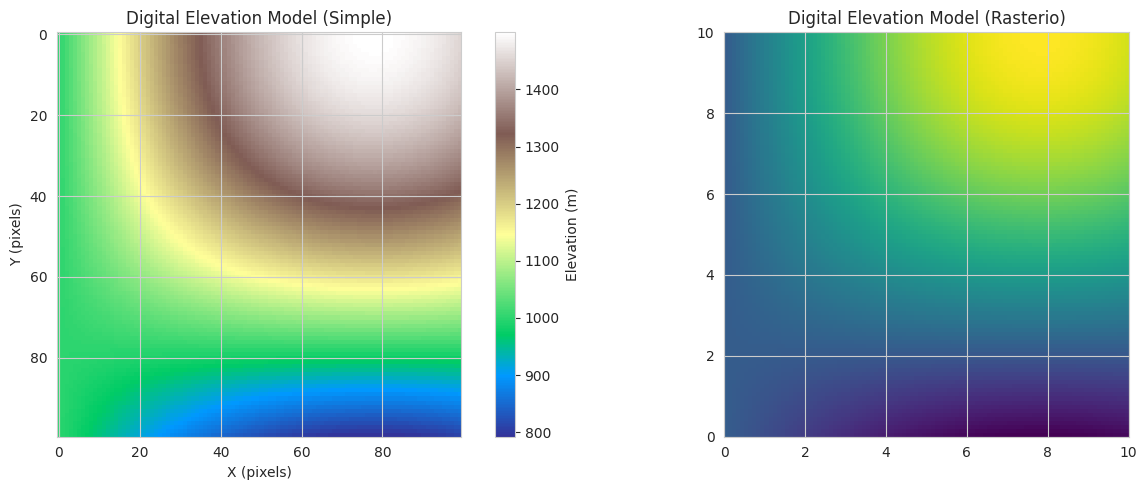

In [ ]:
# Plot raster data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Simple plot
axes[0].imshow(dem_data, cmap='terrain')
axes[0].set_title('Digital Elevation Model (Simple)')
axes[0].set_xlabel('X (pixels)')
axes[0].set_ylabel('Y (pixels)')
plt.colorbar(axes[0].images[0], ax=axes[0], label='Elevation (m)')

# With rasterio show
with rasterio.open('data/sample_dem.tif') as src:
    show(src, ax=axes[1], cmap='viridis')
    axes[1].set_title('Digital Elevation Model (Rasterio)')

plt.tight_layout()
plt.show()

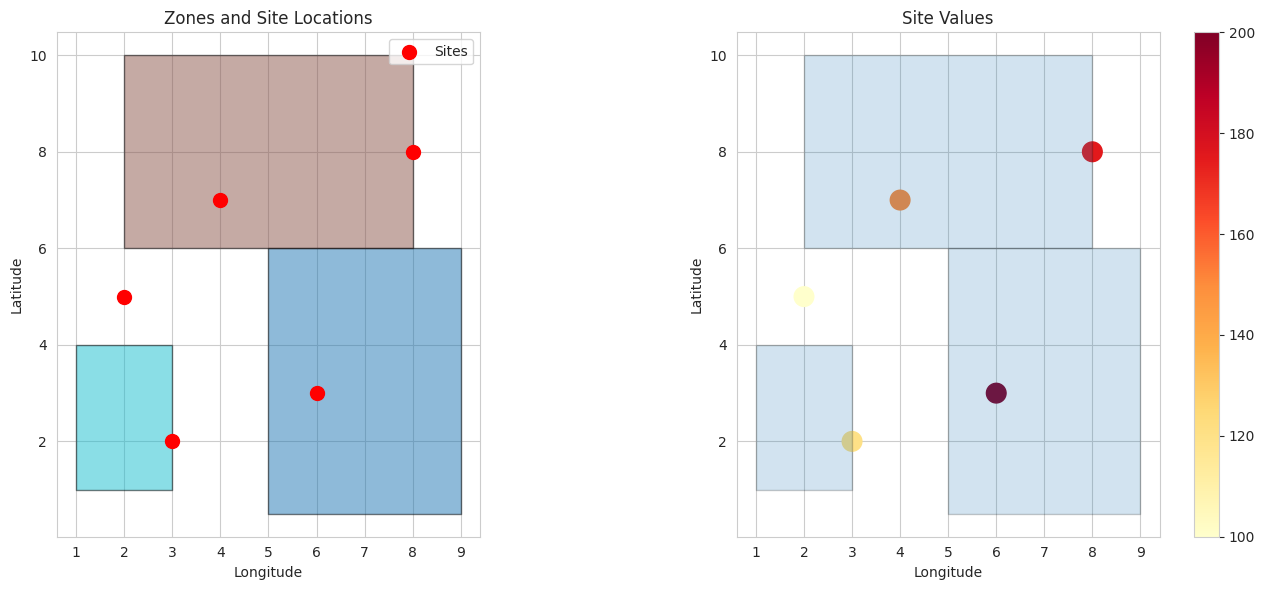

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot zones
zones.plot(ax=axes[0], alpha=0.5, edgecolor='k', column='zone', legend=True)
points.plot(ax=axes[0], color='red', markersize=100, label='Sites')
axes[0].set_title('Zones and Site Locations')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].legend()

# Plot with values
points.plot(ax=axes[1], column='value', cmap='YlOrRd', markersize=200, legend=True)
zones.plot(ax=axes[1], alpha=0.2, edgecolor='black')
axes[1].set_title('Site Values')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()

In [ ]:
# Create interactive map
m = folium.Map(location=[5, 5], zoom_start=6)

# Add zones to map
for idx, row in zones.iterrows():
    geo = folium.GeoJson(
        data=row['geometry'].__geo_interface__,
        style_function=lambda x: {'color': 'blue', 'opacity': 0.3}
    )
    folium.Popup(f"Zone: {row['zone']}").add_to(geo)
    geo.add_to(m)

# Add points to map
for idx, row in points.iterrows():
    folium.CircleMarker(
        location=[row['geometry'].y, row['geometry'].x],
        radius=10,
        popup=f"{row['name']}: {row['value']}",
        color='red',
        weight=2
    ).add_to(m)

display(m)

In [ ]:
# 1. Buffer analysis
points_buffered = points.copy()
points_buffered['geometry'] = points.geometry.buffer(1.5)

# 2. Spatial join
spatial_join = gpd.sjoin(points, zones, how='left', predicate='within')
print("Points within zones:")
print(spatial_join[['name', 'zone']])

# 3. Calculate distances
from shapely.geometry import Point
ref_point = Point(5, 5)
points['distance_to_center'] = points.geometry.distance(ref_point)
print("\nDistance to center (5, 5):")
print(points[['name', 'distance_to_center']])

# 4. Dissolve (aggregate)
zones_dissolved = zones.dissolve(by='zone', aggfunc='sum')
print("\nDissolved zones:")
print(zones_dissolved)

Points within zones:
     name          zone
0  Site A           NaN
1  Site B        Forest
2  Site C  Agricultural
3  Site D           NaN
4  Site E           NaN

Distance to center (5, 5):
     name  distance_to_center
0  Site A            3.000000
1  Site B            2.236068
2  Site C            2.236068
3  Site D            4.242641
4  Site E            3.605551

Dissolved zones:
                                               geometry  id  area
zone                                                             
Agricultural  POLYGON ((9 0.5, 9 6, 5 6, 5 0.5, 9 0.5))   2   150
Forest            POLYGON ((8 6, 8 10, 2 10, 2 6, 8 6))   3   200
Urban               POLYGON ((3 1, 3 4, 1 4, 1 1, 3 1))   1    50


In [ ]:
from rasterstats import zonal_stats

# Calculate statistics of raster within vector zones
stats = zonal_stats(zones, dem_data, affine=rasterio.open('data/sample_dem.tif').transform)

zones['mean_elevation'] = [stat['mean'] for stat in stats]
zones['max_elevation'] = [stat['max'] for stat in stats]
zones['min_elevation'] = [stat['min'] for stat in stats]

print("Elevation statistics by zone:")
print(zones[['zone', 'mean_elevation', 'min_elevation', 'max_elevation']])

Elevation statistics by zone:
           zone  mean_elevation  min_elevation  max_elevation
0         Urban     1012.332541     937.732300    1097.045972
1  Agricultural     1098.179757     838.835212    1345.439353
2        Forest     1355.315683    1138.649561    1499.993847


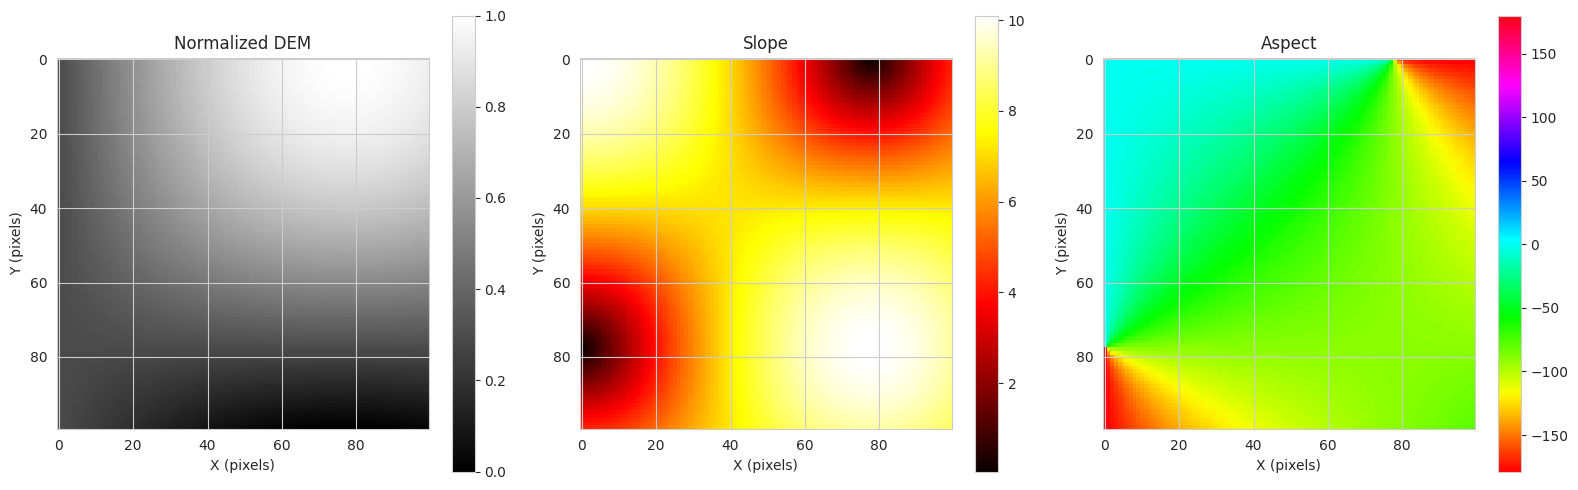

In [ ]:
# Raster map algebra
dem_normalized = (dem_data - dem_data.min()) / (dem_data.max() - dem_data.min())

# Slope calculation (simplified)
x_gradient = np.gradient(dem_data, axis=1)
y_gradient = np.gradient(dem_data, axis=0)
slope = np.sqrt(x_gradient**2 + y_gradient**2)

# Aspect calculation
aspect = np.arctan2(y_gradient, x_gradient) * 180 / np.pi

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(dem_normalized, cmap='gray')
axes[0].set_title('Normalized DEM')
im0 = axes[0].imshow(dem_normalized, cmap='gray')
plt.colorbar(im0, ax=axes[0])

axes[1].imshow(slope, cmap='hot')
axes[1].set_title('Slope')
im1 = axes[1].imshow(slope, cmap='hot')
plt.colorbar(im1, ax=axes[1])

axes[2].imshow(aspect, cmap='hsv')
axes[2].set_title('Aspect')
im2 = axes[2].imshow(aspect, cmap='hsv')
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')

plt.tight_layout()
plt.show()

In [ ]:
# Save processed vector data
points.to_file('data/points_with_distance.geojson', driver='GeoJSON')
zones.to_file('data/zones_with_elevation.geojson', driver='GeoJSON')

# Save raster outputs
def save_raster(data, output_path, original_src):
    """Helper function to save raster data"""
    profile = original_src.meta
    profile.update(dtype=data.dtype)

    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(data, 1)
    print(f"✓ Saved: {output_path}")

with rasterio.open('data/sample_dem.tif') as src:
    save_raster(dem_normalized, 'data/dem_normalized.tif', src)
    save_raster((slope * 100).astype(np.uint8), 'data/slope.tif', src)

# Save as GeoPackage (multi-layer format)
points.to_file('data/geospatial_data.gpkg', layer='points', driver='GPKG')
zones.to_file('data/geospatial_data.gpkg', layer='zones', driver='GPKG')
print("✓ Saved: data/geospatial_data.gpkg")

✓ Saved: data/dem_normalized.tif
✓ Saved: data/slope.tif
✓ Saved: data/geospatial_data.gpkg


In [ ]:
# Create a zip file of results
!cd data && zip -r -q results.zip *.tif *.geojson *.gpkg && cd ..
print("Results saved to data/results.zip")

# List all output files
import os
print("\nGenerated files:")
for f in os.listdir('data'):
    size = os.path.getsize(f'data/{f}') / 1024
    print(f"  - {f} ({size:.1f} KB)")

Results saved to data/results.zip

Generated files:
  - ne_10m_admin_0_countries.prj (0.1 KB)
  - countries.zip (4814.9 KB)
  - ne_10m_admin_0_countries.README.html (38.5 KB)
  - ne_10m_admin_0_countries.dbf (857.9 KB)
  - ne_10m_admin_0_countries.shp (8599.8 KB)
  - slope.tif (10.1 KB)
  - sample_points.geojson (0.9 KB)
  - ne_10m_admin_0_countries.shx (2.1 KB)
  - geospatial_data.gpkg (116.0 KB)
  - points_with_distance.geojson (1.1 KB)
  - ne_10m_admin_0_countries.cpg (0.0 KB)
  - results.zip (159.3 KB)
  - sample_dem.tif (78.5 KB)
  - sample_dem.tar.gz (0.0 KB)
  - zones_with_elevation.geojson (1.1 KB)
  - ne_10m_admin_0_countries.VERSION.txt (0.0 KB)
  - dem_normalized.tif (78.5 KB)
  - sample_zones.geojson (0.8 KB)
